## Student Performance Indicator

#### [Kaggle link for the ML problem and dataset](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977)

### Life cycle of a Machine Learning Project

- understanding the problem statement
- data collection
- data checks to perform
- evaluatory data analysis
- data pre-processing
- model training
- choosing the best model

### 1) Problem Statement
- this project understands how the students performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of Education, Lunch and Test preparation course

### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required packages
#### Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv("data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### showing last 5 records

In [3]:
df.tail()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


#### Shape of the dataset

In [4]:
df.shape

(1000, 8)

### 2.2 Dataset Information
- gender: sex of students -> (Male/Female)
- race/ethnicity: ethnicity of students -> (Group A, B, C, D or E)
- parental_level_of_education: parents' final education -> bachelors degree,some college, masters degree, associates degree, high school)
- lunch: having lunch before test (standard or free/reduced)
- test_preparation_course: complete or not complete before test
- math score
- reading score
- writing score

### 3) Data checks to perform
- check missing values
- check duplicates
- check data type
- check the number of unique values of each column
- check statistics of data set
- check various categories present in the different categorical column

#### 3.1 Check Missing Values


In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There are no missing values in the dataset

#### 3.2 Check Duplicates

In [6]:
df.duplicated().sum()

0

There are no duplicates in the data set

#### 3.3 Check Data Types

In [7]:
# check null and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

#### 3.5 Check statistics of the dataset


In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insights:
- From the above description of numerical data, all mean are very close to each other - between 66 and 68.5
- All standard deviations are also very close, between 14.6 and 15.19
- while min score for math is 0, reading and writing have a higher minimum score of 10 and 17 respectively

#### 3.6 Exploring data

In [10]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
gender_categories = [sex for sex in df["gender"].unique()]
print(f"Categories in gender: {gender_categories}")

race_categories = [race for race in df["race_ethnicity"].unique()]
print(f"Categories in race_ethnicity: {race_categories}")

parental_education_categories = [lvl for lvl in df["parental_level_of_education"].unique()]
print(f"Categories in parental_level_of_education: {parental_education_categories}")

lunch_categories = [food for food in df["lunch"].unique()]
print(f"Categories in lunch: {lunch_categories}")

test_prep_categories = [course for course in df["test_preparation_course"].unique()]
print(f"Categories in test_preparation_course: {test_prep_categories}")

Categories in gender: ['female', 'male']
Categories in race_ethnicity: ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in parental_level_of_education: ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in lunch: ['standard', 'free/reduced']
Categories in test_preparation_course: ['none', 'completed']


In [12]:
# define numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != "object"]
# numeric_features = [feature for feature in df.columns if df[feature].dtype != "O"]

categorical_features = [feature for feature in df.columns if df[feature].dtype == "object"]

print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [13]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


#### 3.8 Adding columns for total score and average --> Feature Engineering

In [14]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average_score"] = df["total_score"]/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
# df[df["reading_score"] == 100]["reading_score"].value_counts() --> counts number of tuples along with differnt value
# #

In [16]:
reading_full = df[df["reading_score"] == 100]["average_score"].count() # counts total number of tuples for all attributes
writing_full = df[df["writing_score"] == 100]["average_score"].count()
math_full = df[df["math_score"] == 100]["average_score"].count()

print(f"Number of students with full marks in Maths: {math_full}")
print(f"Number of students with full marks in writing: {writing_full}")
print(f"Number of students with full marks in Reading: {reading_full}")


Number of students with full marks in Maths: 7
Number of students with full marks in writing: 14
Number of students with full marks in Reading: 17


In [17]:
reading_less_than_20 = df[df["reading_score"] < 20]["average_score"].count()
writing_less_than_20 = df[df["writing_score"] < 20]["average_score"].count()
math_less_than_20 = df[df["math_score"] < 20]["average_score"].count()

print(f"Number of students with less than 20 marks in Maths: {math_less_than_20}")
print(f"Number of students with less than 20 marks in writing: {writing_less_than_20}")
print(f"Number of students with less than 20 marks in Reading: {reading_less_than_20}")

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in writing: 3
Number of students with less than 20 marks in Reading: 1


Insights 
- The students have performed the worst in Mathematics, while the best performance was in reading

### Exploring Data (Visualization)

#### 4.1 Visualize average score distribution to make some conclusion
- Histogram
- Kernel Distribution Function

#### Histogram & KDE

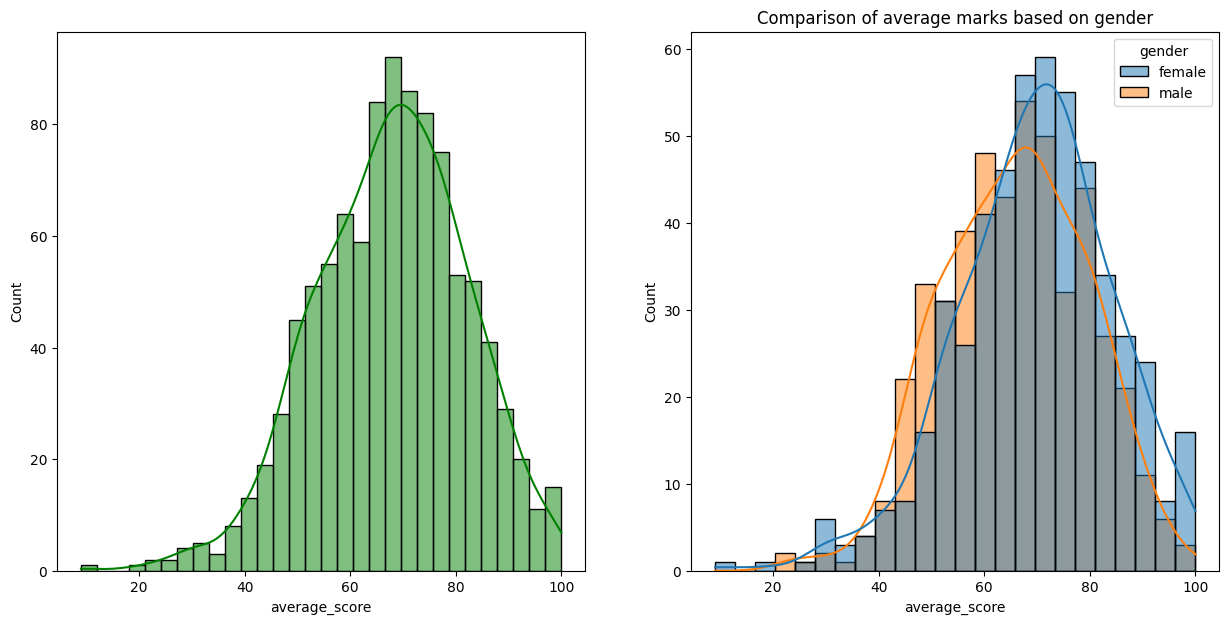

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x="average_score", bins=30, kde=True, color="g")   
plt.subplot(122)
sns.histplot(data=df,x="average_score", kde=True,hue="gender")
plt.title("Comparison of average marks based on gender")
plt.show()

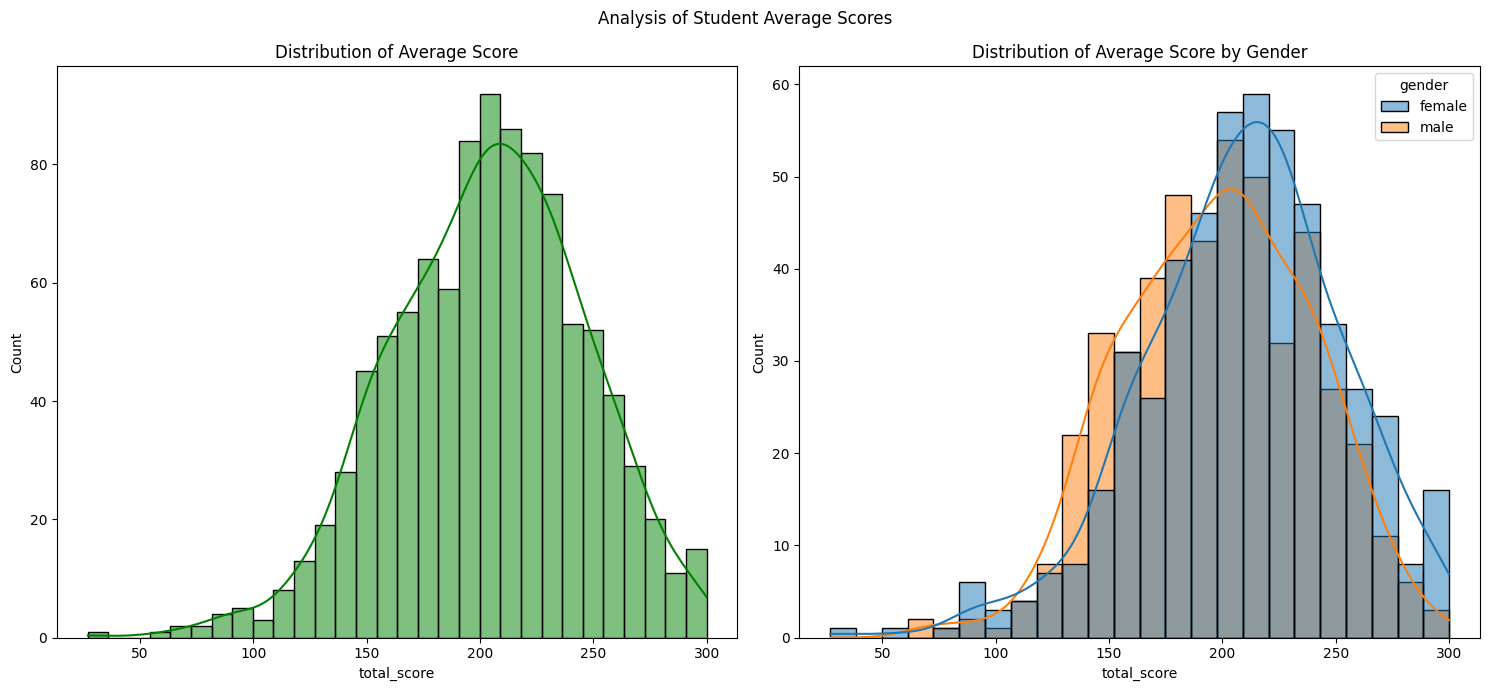

In [19]:
fig, axes = plt.subplots(1,2,figsize=(15,7))
# 1st subplot ax[i] is equivalent to plt.subplot() 
# plt.subplot(1,2,1)
sns.histplot(data=df,x="total_score",bins=30,kde=True,color="g",ax=axes[0])
axes[0].set_title("Distribution of Average Score")

# 2nd subplot
# plt.subplot(1,2,2)
sns.histplot(data=df, x="total_score", kde=True, hue="gender",ax=axes[1])
axes[1].set_title("Distribution of Average Score by Gender")

# for overall title
fig.suptitle("Analysis of Student Average Scores")

plt.tight_layout()
plt.show()

Insight: females are performing better


In [20]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score'],
      dtype='object')

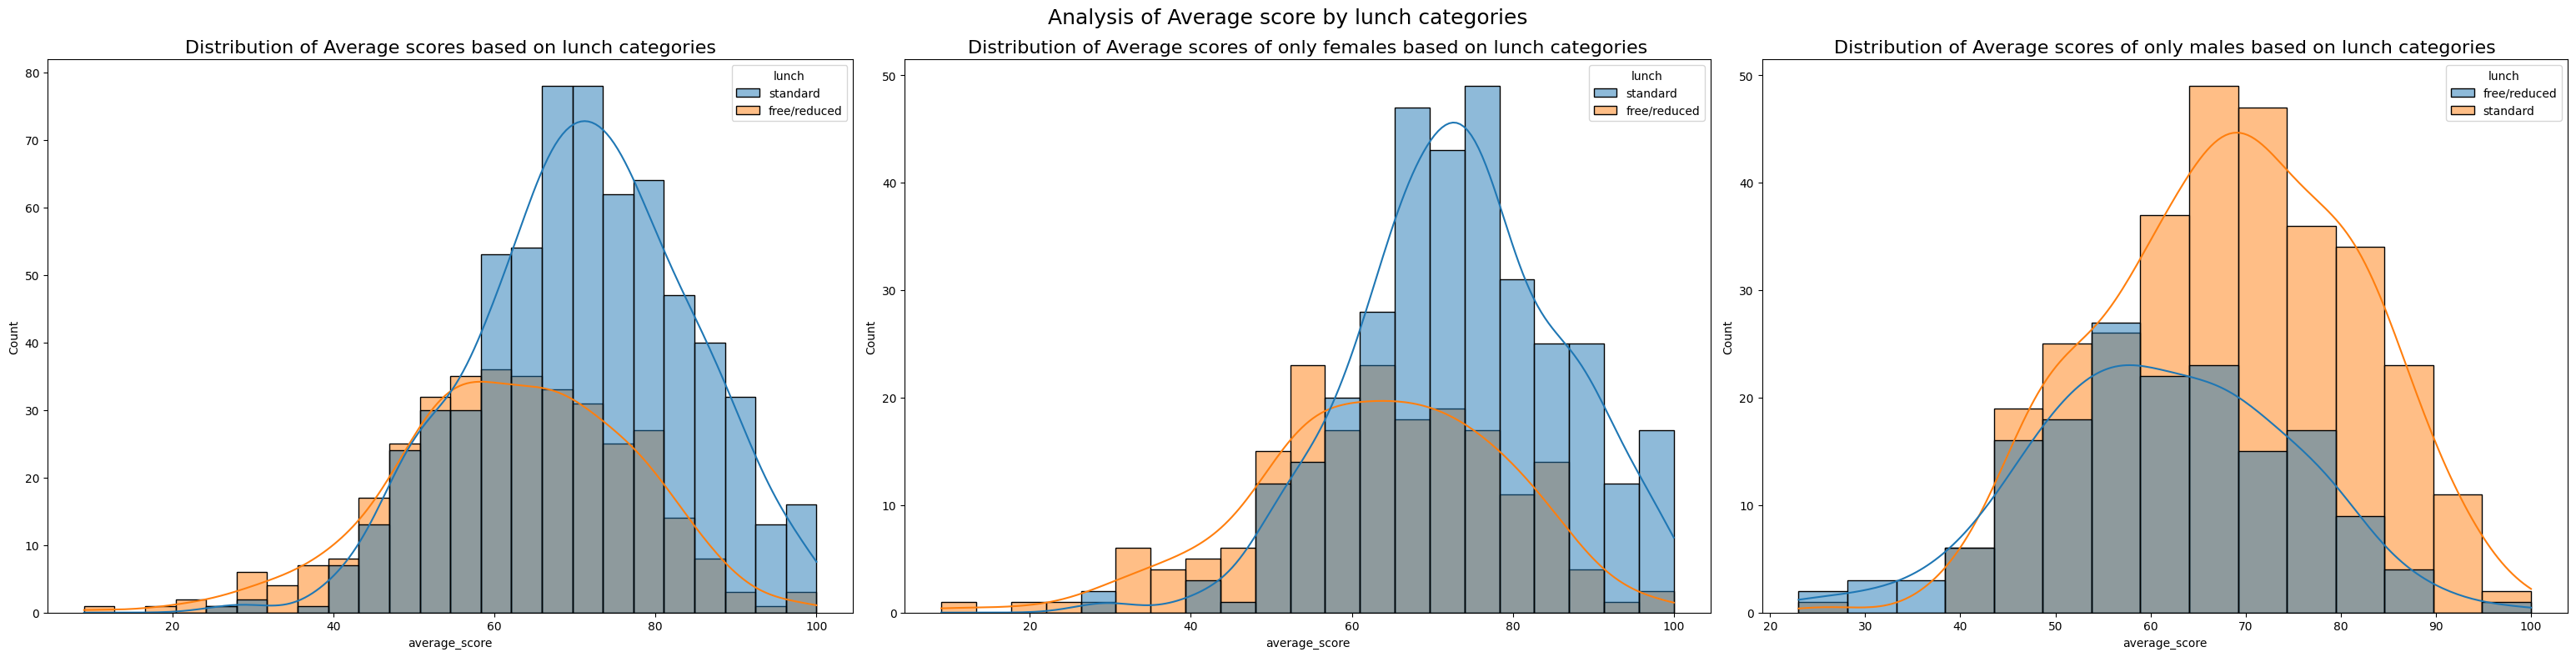

In [21]:
fig,axs = plt.subplots(1,3,figsize=(31,8))

sns.histplot(data=df, x="average_score", kde=True, hue="lunch", ax=axs[0])
axs[0].set_title("Distribution of Average scores based on lunch categories",fontsize=16)

sns.histplot(data=df[df["gender"] == "female"], x="average_score", kde=True, hue="lunch",ax=axs[1])
axs[1].set_title("Distribution of Average scores of only females based on lunch categories",fontsize=16)

sns.histplot(data=df[df["gender"] == "male"], x="average_score", kde=True, hue="lunch",ax=axs[2])
axs[2].set_title("Distribution of Average scores of only males based on lunch categories",fontsize=16)

plt.suptitle("Analysis of Average score by lunch categories",fontsize=18)

plt.tight_layout()
plt.show()


Insight: 
- standard lunch helps students perform better 
- standard lunch helps students perform better in exams irrespective of their gender

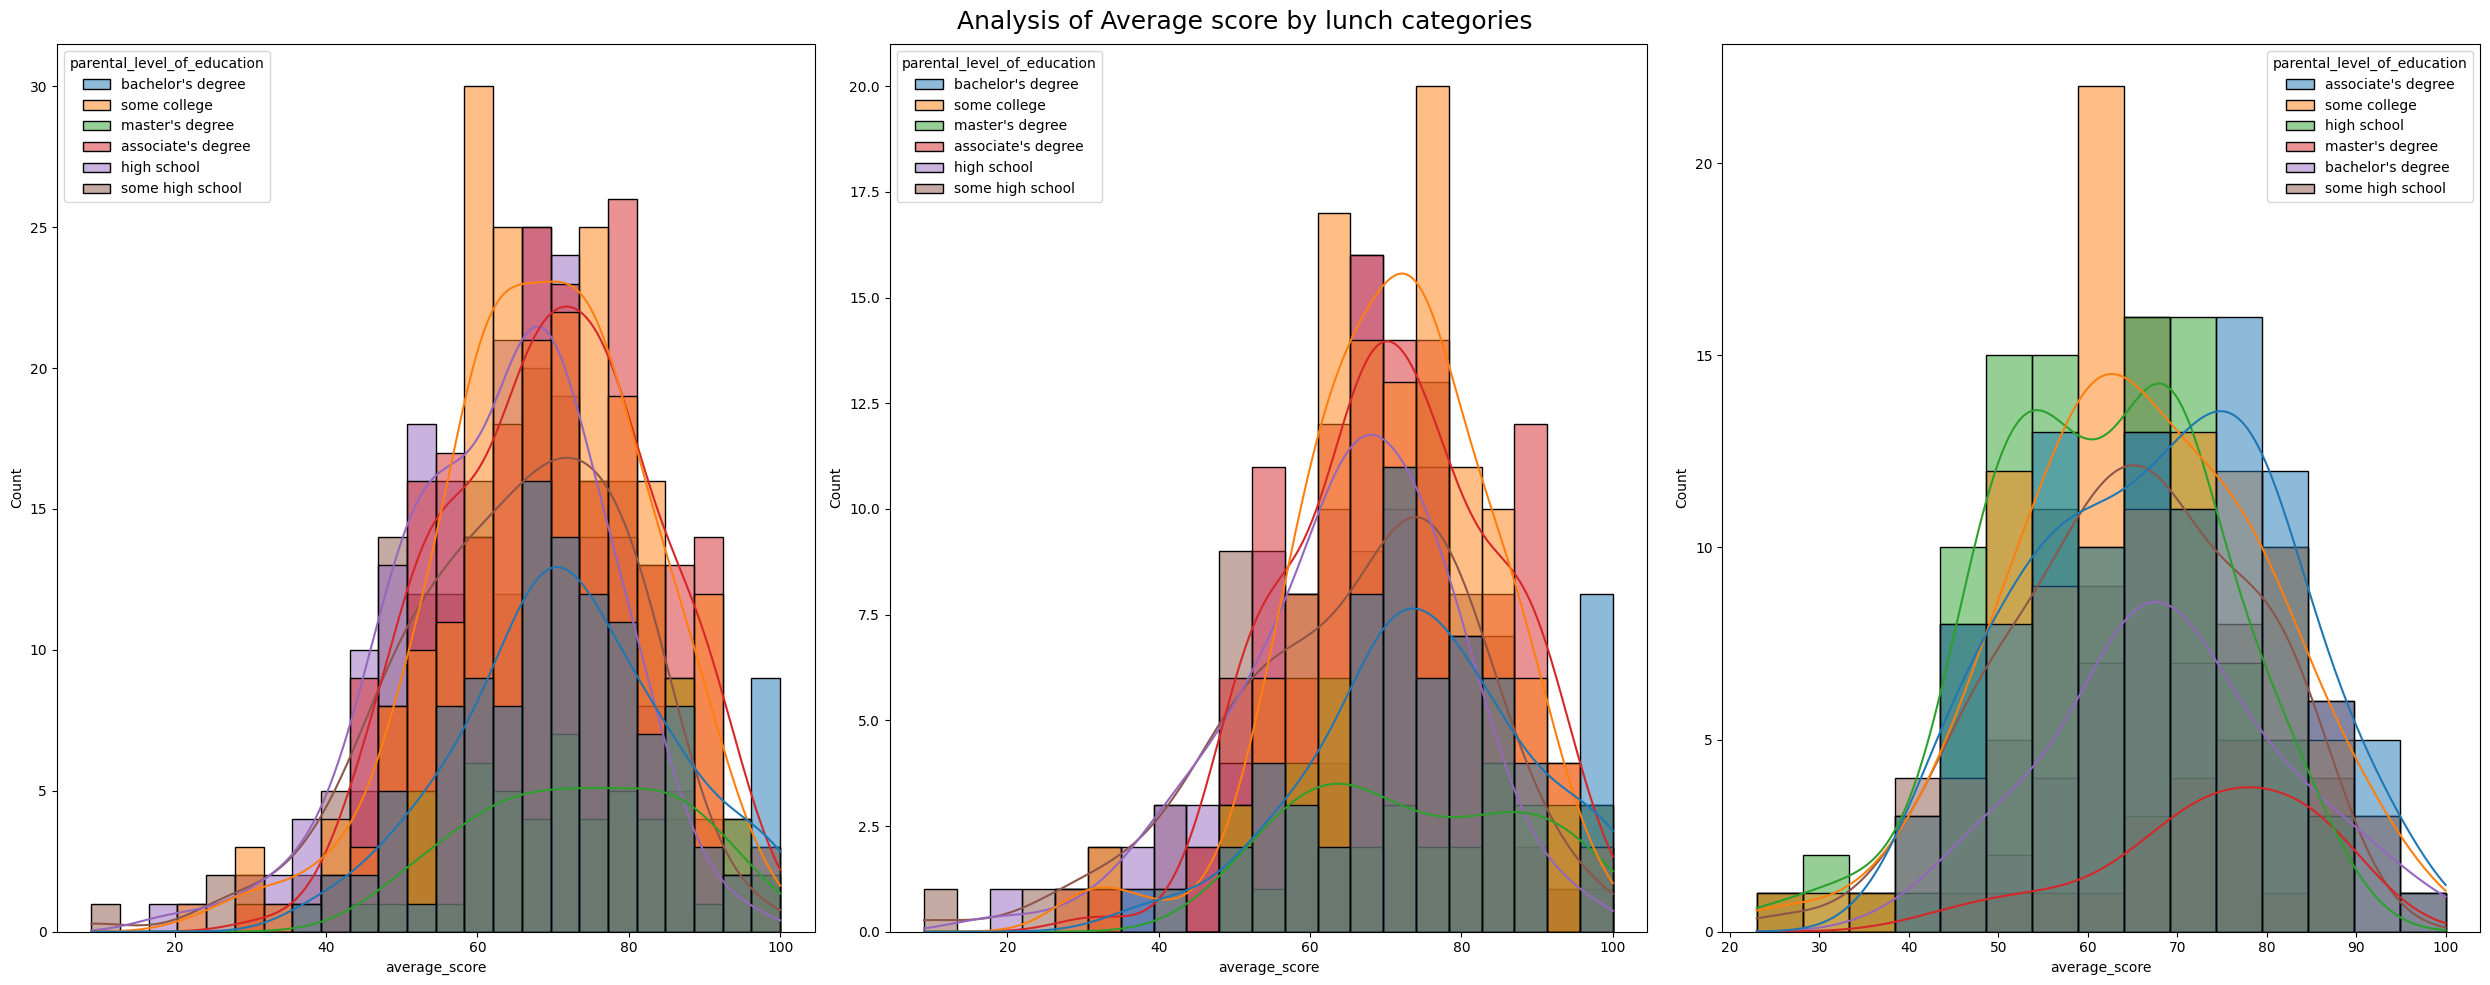

In [22]:
fig,axs = plt.subplots(1,3,figsize=(25,10))

sns.histplot(data=df, x="average_score", kde=True, hue="parental_level_of_education", ax=axs[0])
# axs[0].set_title("Distribution of Average scores based on parents level of education categories",fontsize=16)

sns.histplot(data=df[df["gender"] == "female"], x="average_score", kde=True, hue="parental_level_of_education",ax=axs[1])
# axs[1].set_title("Distribution of Average scores of only females based on parents level of education categories",fontsize=16)

sns.histplot(data=df[df["gender"] == "male"], x="average_score", kde=True, hue="parental_level_of_education",ax=axs[2])
# axs[2].set_title("Distribution of Average scores of only males based on parents level of education categories",fontsize=16)

plt.suptitle("Analysis of Average score by lunch categories",fontsize=18)

plt.tight_layout()
plt.show()


Insight:
- In genereal, parental level of education seems to have no impace on the averge score.
- 2nd plot shows parental education level of some college or associates degree helps the male child perform better
- 3rd plot shows parental education does not affect the female child's performace in tests

In [23]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score'],
      dtype='object')

In [24]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [25]:
import pprint
# pprint.pp(categorical_features)
# pprint.pp(f"Categorical features: {categorical_features} \nNumeric Features: {numeric_features}")
print(f"Categorical features: {categorical_features} \nNumeric Features: {numeric_features}")

Categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course'] 
Numeric Features: ['math_score', 'reading_score', 'writing_score']


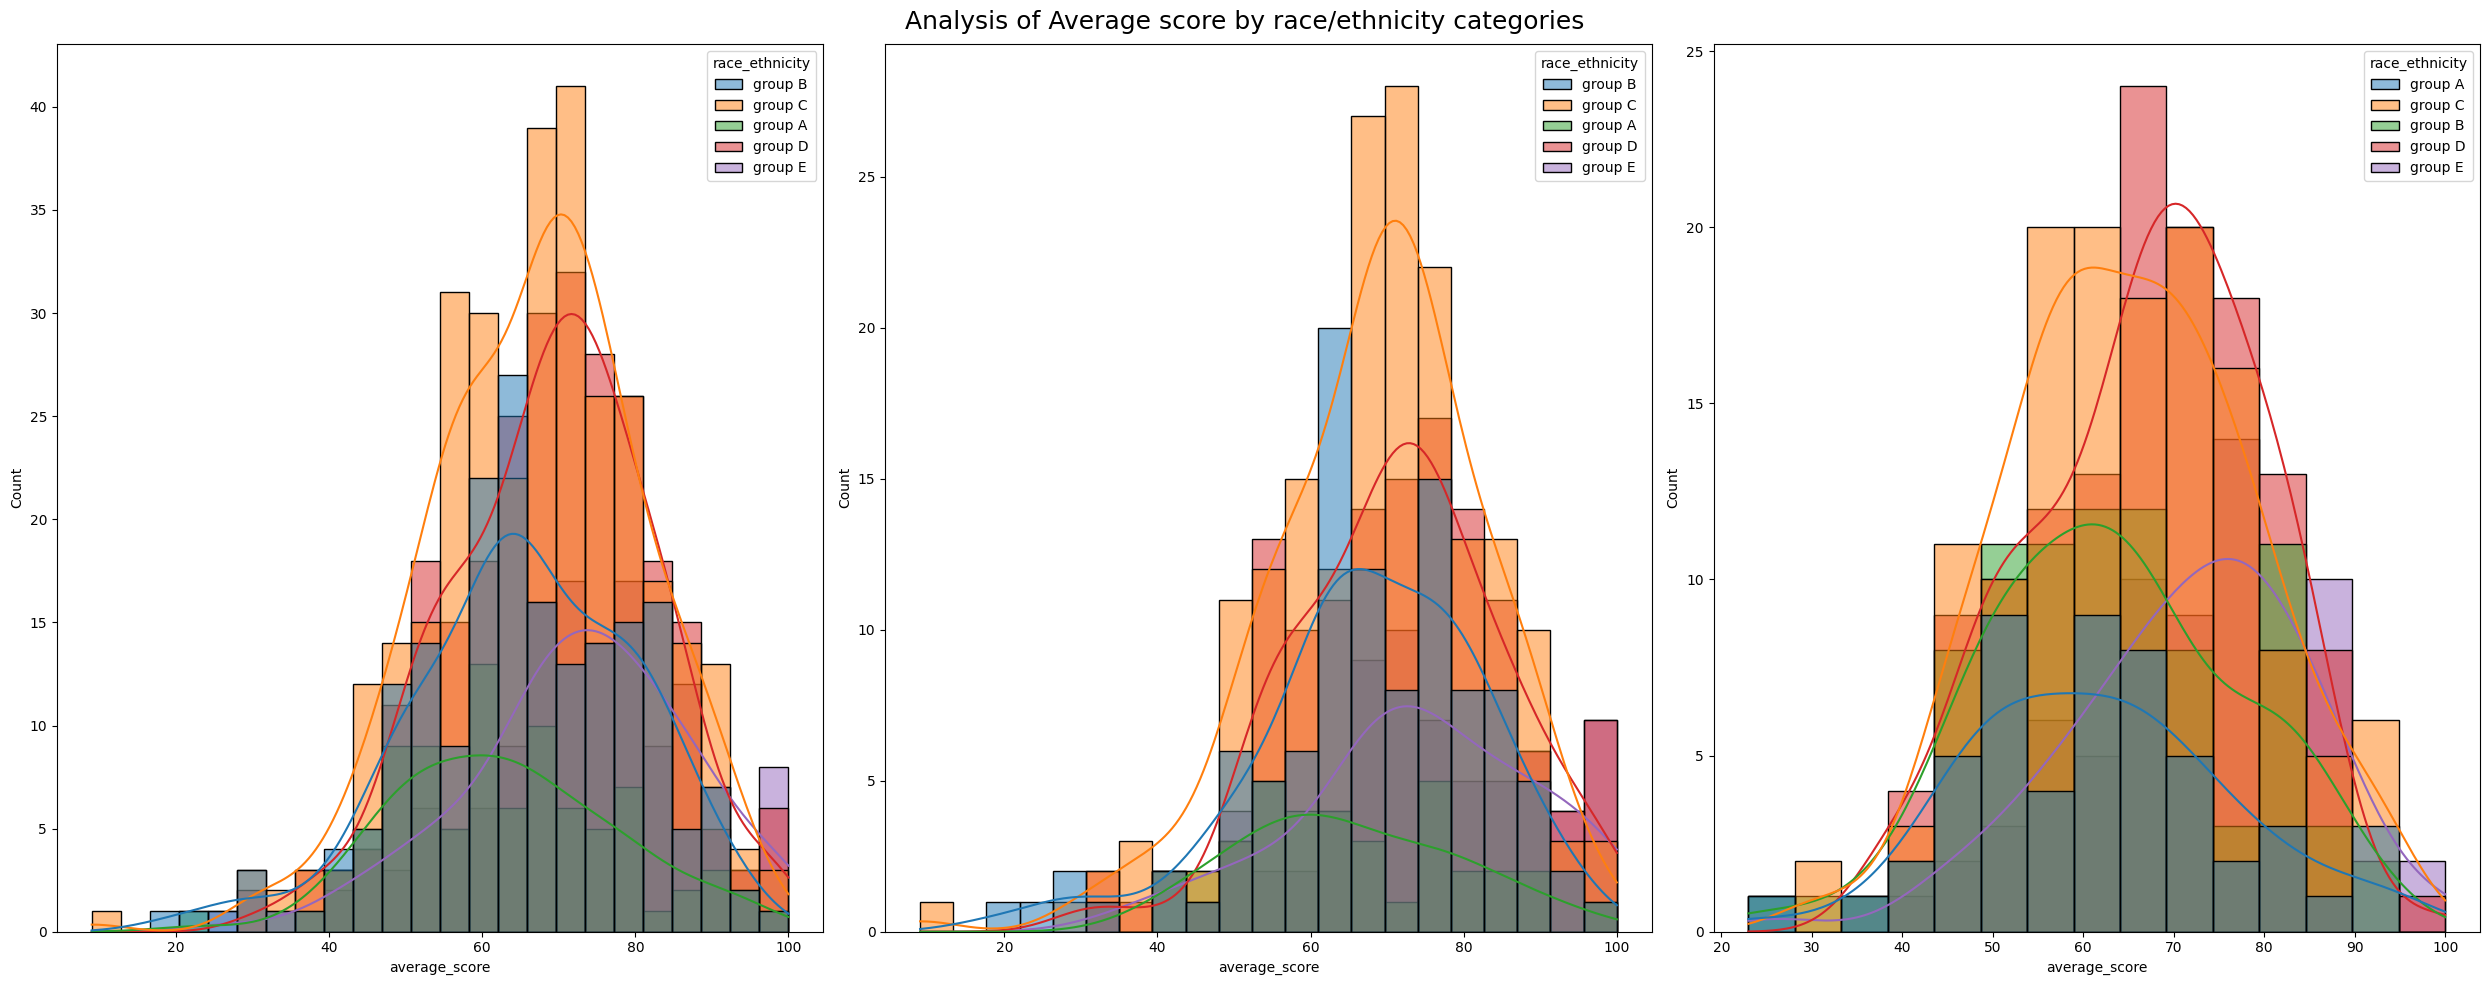

In [26]:
ig,axs = plt.subplots(1,3,figsize=(25,10))

sns.histplot(data=df, x="average_score", kde=True, hue="race_ethnicity", ax=axs[0])
# axs[0].set_title("Distribution of Average scores based on parents level of education categories",fontsize=16)

sns.histplot(data=df[df["gender"] == "female"], x="average_score", kde=True, hue="race_ethnicity",ax=axs[1])
# axs[1].set_title("Distribution of Average scores of only females based on parents level of education categories",fontsize=16)

sns.histplot(data=df[df["gender"] == "male"], x="average_score", kde=True, hue="race_ethnicity",ax=axs[2])
# axs[2].set_title("Distribution of Average scores of only males based on parents level of education categories",fontsize=16)

plt.suptitle("Analysis of Average score by race/ethnicity categories",fontsize=18)

plt.tight_layout()
plt.show()

Insight:
- In general, Group C students perform the best in exams followed by group D, Group B and lastly Group A.
- Group A and Group B perform poorly irrespective of their gender